In [16]:
# we r just intializing the Clustering only
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs

# **KMeans Clustering**

In [17]:
X,y_true = make_blobs(n_samples=500, centers=3,cluster_std=0.60,random_state = 42)
df = pd.DataFrame(X,columns=['Feature_1','Feature_2'])

In [18]:
df

,Feature_1,Feature_2
0,-6.190063,-7.302015
1,3.021747,1.940593
2,5.953761,1.488191
3,-2.744463,8.136177
4,5.360607,1.728324
...,...,...
495,-6.040014,-6.325329
496,-2.555459,9.218977
497,4.438408,2.974583
498,-7.193261,-6.250704


In [19]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#using the elbow method , we need to find the WCSS
inertia = []
K_range = range(1,11)

for k in K_range:
  kmeans = KMeans(n_clusters=k,random_state=42)
  kmeans.fit(X_scaled)
  inertia.append(kmeans.inertia_)

inertia

[1000.0000000000006,
 297.8954141051723,
 11.575484723104985,
 9.752067977356848,
 8.257175272446279,
 6.917577320416797,
 6.334755391595288,
 5.704177177901426,
 5.060234133532074,
 4.7623618981303935]

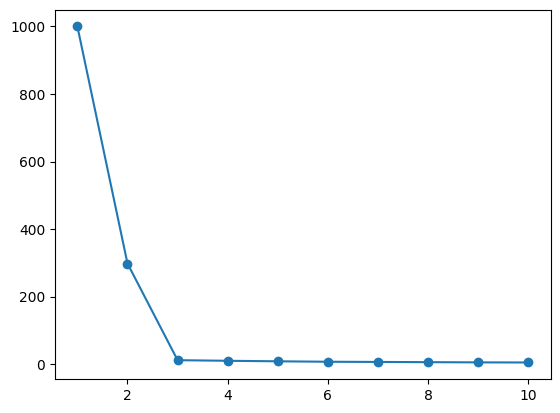

In [20]:
plt.plot(K_range,inertia,marker='o')

In [21]:
kmeans_final = KMeans(n_clusters=3,random_state=42)
cluster_labels = kmeans_final.fit_predict(X_scaled)
df['cluster'] = cluster_labels

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

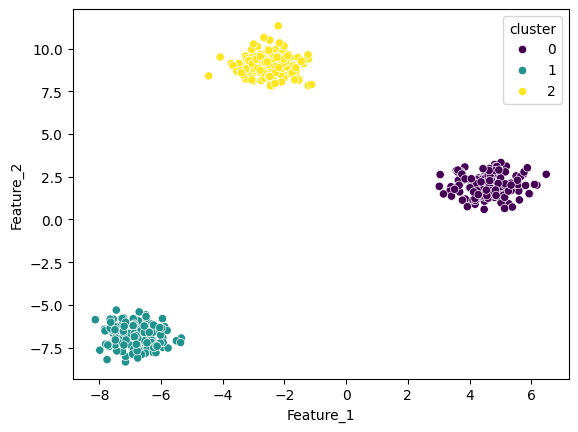

In [22]:
sns.scatterplot(x=df['Feature_1'],y=df['Feature_2'],hue=df['cluster'],palette='viridis')

In [24]:
from sklearn.datasets import make_moons

In [26]:
X,y_true = make_moons(n_samples=500,random_state=42,noise=0.05)
#noise adds random variation to the points
from sklearn.cluster import KMeans, DBSCAN
df = pd.DataFrame(X,columns=['Feature_1','Feature_2'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

kmeans = KMeans(n_clusters=2,random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)
df['cluster'] = kmeans_labels

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

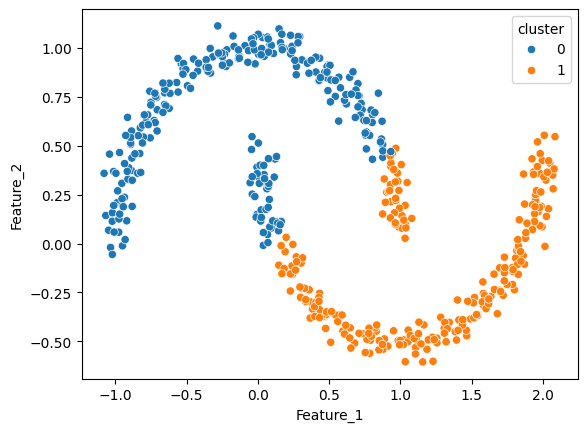

In [27]:
sns.scatterplot(x=df['Feature_1'],y=df['Feature_2'],hue=df['cluster'],palette='tab10')

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

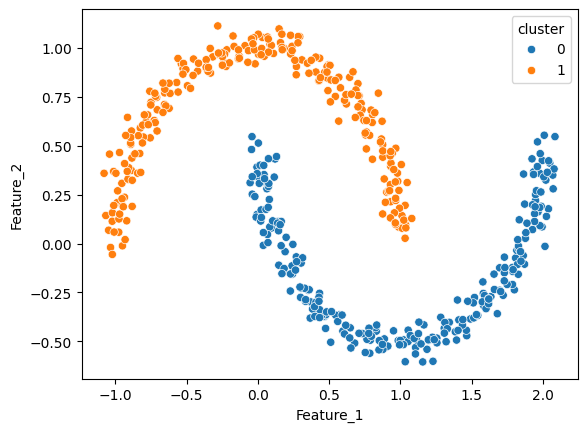

In [30]:
dbscan = DBSCAN(eps=0.3,min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)
df['cluster'] = dbscan_labels

sns.scatterplot(x=df['Feature_1'],y=df['Feature_2'],hue=df['cluster'],palette='tab10')